# AlphaLens Modeling Data Audit

This notebook verifies the data available for a point-in-time 30-trading-day excess-return model. It audits market history, event coverage, FinBERT coverage, and forward-window availability before any features or targets are built. Event anchors use the first trading session strictly after each observed event date because release times are not consistently available.

**Point-in-time rule:** an earnings call becomes observable on `call_date`, and an SEC filing becomes observable on `filing_date`. Fiscal labels and report dates describe earlier periods and must not be used as feature timestamps.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pipelines.ml.data_audit import run_data_audit

pd.set_option('display.max_columns', 30)
plt.style.use('seaborn-v0_8-whitegrid')

## Run the reproducible audit

The notebook delegates database logic to `pipelines.ml.data_audit`, so the same checks can run from PowerShell and CI without executing notebook cells manually.

In [2]:
report = run_data_audit(horizon=30)
print(f'Audit generated at {report.generated_at:%Y-%m-%d %H:%M:%S %Z}')

Audit generated at 2026-09-17 01:48:21 UTC


## Dataset inventory

A missing optional dataset is a planned feature gap. A missing required dataset prevents the audit from running.

In [3]:
display(report.inventory)

,dataset,role,required_for_audit,available,rows
0,companies,reference,True,True,20.0
1,market_prices,market,True,True,26334.0
2,filings,SEC events,True,True,399.0
3,filing_chunks,SEC text,True,True,32074.0
4,filing_chunk_sentiment,SEC sentiment,True,True,15302.0
5,earnings_transcripts,earnings events,True,True,359.0
6,earnings_transcript_turns,earnings text,True,True,19939.0
7,earnings_transcript_turn_sentiment,earnings sentiment,True,True,19939.0
8,earnings_results,earnings fundamentals,False,False,NaN


## Market history

SPY is retained as the benchmark. Equal row counts and aligned date ranges reduce accidental benchmark gaps when excess returns are calculated.

In [4]:
display(report.market_coverage)
display(report.market_quality)

,ticker,rows,first_date,last_date,adjusted_close_rows,volume_rows
0,AAPL,1254,2021-08-25,2026-08-24,1254,1254
1,AMZN,1254,2021-08-25,2026-08-24,1254,1254
2,BA,1254,2021-08-25,2026-08-24,1254,1254
3,BAC,1254,2021-08-25,2026-08-24,1254,1254
4,CAT,1254,2021-08-25,2026-08-24,1254,1254
5,COST,1254,2021-08-25,2026-08-24,1254,1254
6,CVX,1254,2021-08-25,2026-08-24,1254,1254
7,GOOGL,1254,2021-08-25,2026-08-24,1254,1254
8,GS,1254,2021-08-25,2026-08-24,1254,1254
9,JNJ,1254,2021-08-25,2026-08-24,1254,1254


,metric,value
0,total_rows,26334
1,missing_price_rows,0
2,nonpositive_price_rows,0
3,invalid_ohlc_rows,0
4,invalid_volume_rows,0
5,rows_without_spy,0


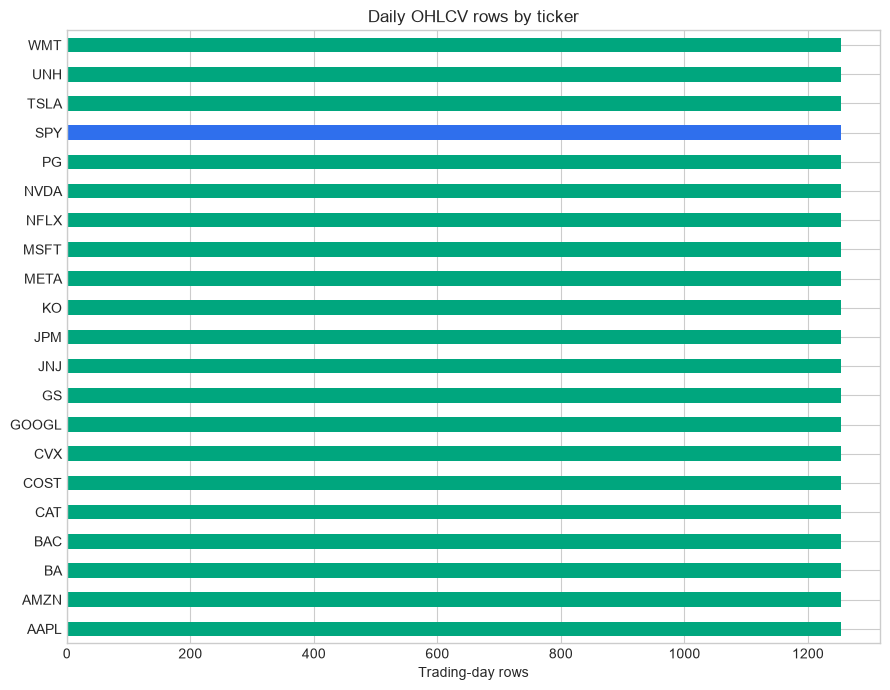

In [5]:
coverage = report.market_coverage.set_index('ticker')['rows'].sort_values()
colors = ['#2f6fed' if ticker == 'SPY' else '#00a67e' for ticker in coverage.index]
ax = coverage.plot(kind='barh', figsize=(9, 7), color=colors)
ax.set(title='Daily OHLCV rows by ticker', xlabel='Trading-day rows', ylabel='')
plt.tight_layout()
plt.show()

## Event coverage

The first table shows source coverage by company. The second asks a narrower modeling question: how many observed events have enough later prices to calculate a complete 30-trading-day target? Recent events are correctly unavailable rather than assigned incomplete labels.

In [6]:
display(report.event_coverage)
display(report.event_horizon_coverage)

,ticker,transcripts,dated_transcripts,first_call_date,last_call_date,filings_10k,filings_10q,first_filing_date,last_filing_date
0,AAPL,19,19,2022-01-27,2026-07-30,5,15,2021-10-29,2026-07-31
1,AMZN,18,18,2022-04-28,2026-07-30,5,15,2021-10-29,2026-07-31
2,BA,18,18,2022-04-27,2026-07-28,5,15,2021-10-27,2026-07-28
3,BAC,18,18,2022-04-18,2026-07-14,5,15,2021-10-29,2026-07-31
4,CAT,17,17,2022-04-28,2026-08-04,5,15,2021-11-03,2026-08-05
5,COST,18,18,2021-12-09,2026-05-28,5,15,2021-10-06,2026-06-03
6,CVX,18,18,2022-04-29,2026-07-31,5,15,2021-11-04,2026-08-06
7,GOOGL,18,18,2022-04-26,2026-07-22,5,15,2021-10-27,2026-07-23
8,GS,18,18,2022-04-14,2026-07-14,5,15,2021-11-01,2026-08-03
9,JNJ,17,17,2022-04-19,2026-07-15,5,15,2021-10-29,2026-07-23


,source,events,dated_events,forward_horizon_available,forward_horizon_coverage,horizon_trading_days
0,earnings_call,359,359,342,0.9526,30
1,sec_filing,399,399,382,0.9574,30


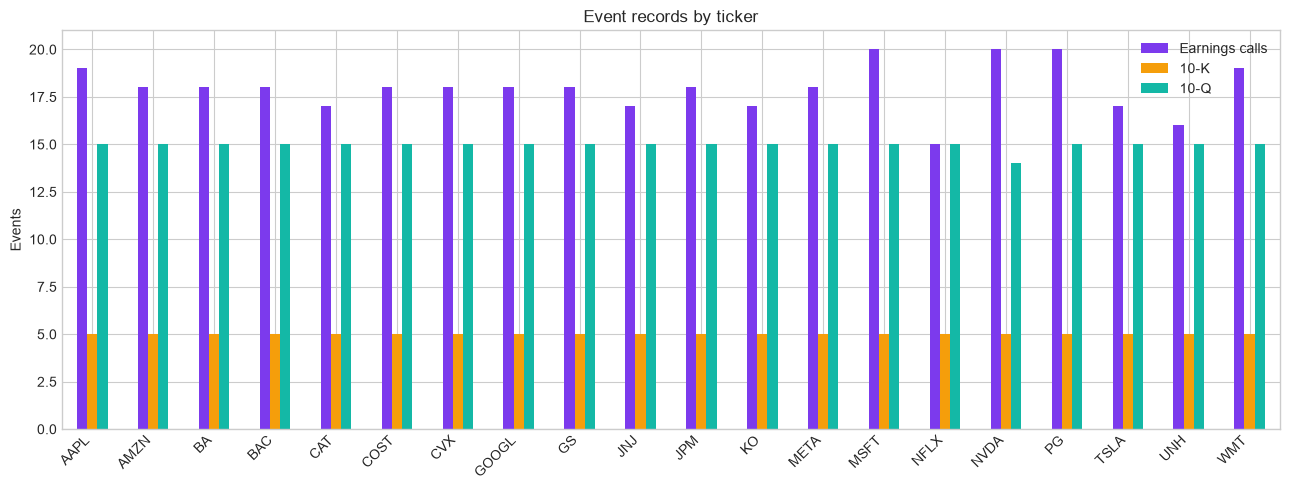

In [7]:
event_counts = report.event_coverage.set_index('ticker')[['transcripts', 'filings_10k', 'filings_10q']]
ax = event_counts.plot(kind='bar', figsize=(13, 5), color=['#7c3aed', '#f59e0b', '#14b8a6'])
ax.set(title='Event records by ticker', xlabel='', ylabel='Events')
ax.legend(['Earnings calls', '10-K', '10-Q'], frameon=False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## FinBERT coverage

Coverage is measured against the exact pinned model revision. Transcript operator turns are excluded from the eligible analytical population; SEC coverage uses only MD&A, Risk Factors, and Market Risk chunks.

In [8]:
display(report.sentiment_coverage)

,source,total_items,eligible_items,scored_items,skipped_items,failed_items,coverage,model_name,model_revision
0,filing_chunks,15302,15302,15302,0,0,1.0,ProsusAI/finbert,4556d13015211d73dccd3fdd39d39232506f3e43
1,transcript_turns,19939,15649,15649,4290,0,1.0,ProsusAI/finbert,4556d13015211d73dccd3fdd39d39232506f3e43


## Audit conclusions

In [9]:
for finding in report.findings:
    print(f'- {finding}')

- Earnings-surprise features are not available yet; add a point-in-time earnings-results source before using them.
- Market history covers 20 equities plus SPY from 2021-08-25 through 2026-08-24.
- Core OHLCV integrity checks passed with no flagged rows.
- earnings_call has 342 of 359 events with a complete 30-trading-day forward window.
- sec_filing has 382 of 399 events with a complete 30-trading-day forward window.
- filing_chunks FinBERT coverage is 100.0% (15,302/15,302 eligible items).
- transcript_turns FinBERT coverage is 100.0% (15,649/15,649 eligible items).
- Use filing_date and call_date as event availability dates; fiscal period and report_date must not be used as feature timestamps.


## Decision for the next stage

The next notebook will define an event-level modeling table and its 30-trading-day excess-return target. It will preserve the event timestamp, anchor trading date, target date, and benchmark prices so every label can be audited. Earnings-surprise features remain out of scope until a point-in-time results source is ingested.